Early attempt on SVMs, using implementation examples from the internet.

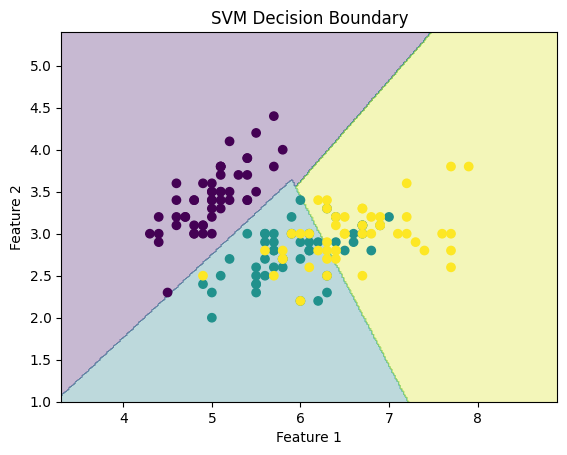

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm, datasets

# Load data
iris = datasets.load_iris()
X = iris.data[:, :2]
y = iris.target

# Train model
model = svm.SVC(kernel='linear')
model.fit(X, y)

# Create grid
x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# Predict all grid points
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict(grid_points)

# Reshape for plotting
Z = Z.reshape(xx.shape)

# Plot decision regions
plt.contourf(xx, yy, Z, alpha=0.3)

# Plot real points
plt.scatter(X[:,0], X[:,1], c=y)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("SVM Decision Boundary")

plt.show()

---

### Download the dataset

In [2]:
import os
from kaggle.api.kaggle_api_extended import KaggleApi
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from dotenv import load_dotenv

load_dotenv()
api = KaggleApi()
api.authenticate()

if not os.path.exists("../datasets/Students Social Media Addiction.csv"):
    api.dataset_download_files(
        "zahranusratt/student-social-media-addiction-analysis-dataset",
        path="../datasets",
        unzip=True
    )
else:
    print("dataset already on local files")

csv_file = os.path.join("../datasets","Students Social Media Addiction.csv")
df = pd.read_csv(csv_file)

print("dataset ready to use")

dataset already on local files
dataset ready to use


### Linear SVC early test

   Avg_Daily_Usage_Hours  Sleep_Hours_Per_Night
0                    5.2                    6.5
1                    2.1                    7.5
2                    6.0                    5.0
3                    3.0                    7.0
4                    4.5                    6.0


/home/fourteenth/Documents/repos/pause-student-social-media-addiction-eda/eda/lib64/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


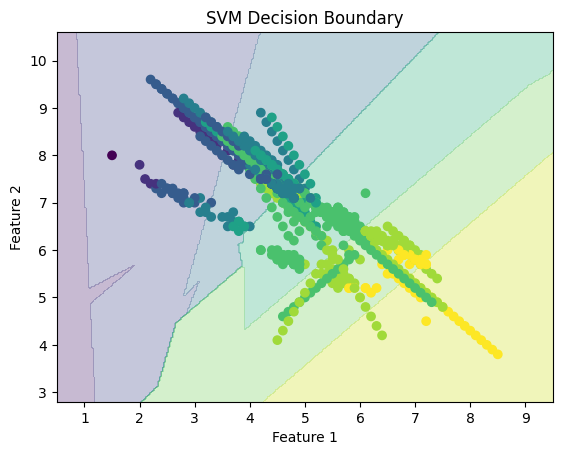

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm, datasets

# print(df.head())
# # Load data
X = df.loc[:,["Avg_Daily_Usage_Hours", "Sleep_Hours_Per_Night"]]
y = df.Addicted_Score
print(X.head())
# print(X, y)

# Train model
model = svm.SVC(kernel='linear')
model.fit(X, y)

# # Create grid
x_min, x_max = X["Avg_Daily_Usage_Hours"].min()-1, X["Avg_Daily_Usage_Hours"].max()+1
y_min, y_max = X["Sleep_Hours_Per_Night"].min()-1, X["Sleep_Hours_Per_Night"].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 350),
    np.linspace(y_min, y_max, 350)
)

# Predict all grid points
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict(grid_points)

# Reshape for plotting
Z = Z.reshape(xx.shape)

# Plot decision regions
plt.contourf(xx, yy, Z, alpha=0.3)

# Plot real points
plt.scatter(X["Avg_Daily_Usage_Hours"], X['Sleep_Hours_Per_Night'],c=y)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("SVM Decision Boundary")

plt.show()

### Linear SVC using polynomial features and scaling

   Avg_Daily_Usage_Hours  Sleep_Hours_Per_Night
0                    5.2                    6.5
1                    2.1                    7.5
2                    6.0                    5.0
3                    3.0                    7.0
4                    4.5                    6.0
classes within the target:  8


/home/fourteenth/Documents/repos/pause-student-social-media-addiction-eda/eda/lib64/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


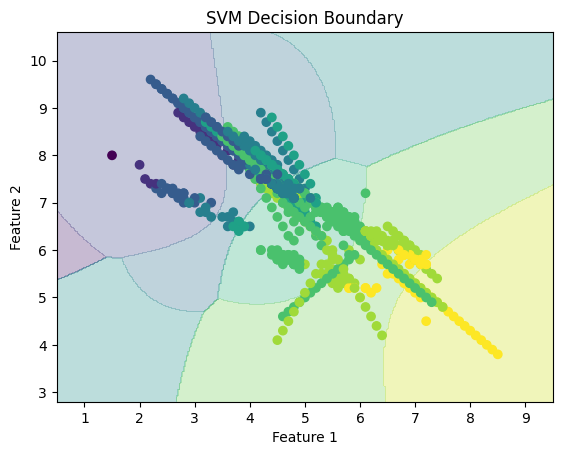

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm, datasets
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import LinearSVC

# print(df.head())
# # Load data
X = df.loc[:,["Avg_Daily_Usage_Hours", "Sleep_Hours_Per_Night"]]
y = df.Addicted_Score
print(X.head())
# print(X, y)
print("classes within the target: ", y.nunique())

polynomial_svm_clf = make_pipeline(
    PolynomialFeatures(degree=3),
    StandardScaler(),
    LinearSVC(C=1, max_iter=10_000, random_state=42)
)
polynomial_svm_clf.fit(X, y)

# Train model
# model = svm.SVC(kernel='linear')
# model.fit(X, y)

# # Create grid
x_min, x_max = X["Avg_Daily_Usage_Hours"].min()-1, X["Avg_Daily_Usage_Hours"].max()+1
y_min, y_max = X["Sleep_Hours_Per_Night"].min()-1, X["Sleep_Hours_Per_Night"].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 350),
    np.linspace(y_min, y_max, 350)
)

# Predict all grid points
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = polynomial_svm_clf.predict(grid_points)

# Reshape for plotting
Z = Z.reshape(xx.shape)

# Plot decision regions
plt.contourf(xx, yy, Z, alpha=0.3)

# Plot real points
plt.scatter(X["Avg_Daily_Usage_Hours"], X['Sleep_Hours_Per_Night'],c=y)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("SVM Decision Boundary")

plt.show()

### RBF early tests

   Avg_Daily_Usage_Hours  Sleep_Hours_Per_Night
0                    5.2                    6.5
1                    2.1                    7.5
2                    6.0                    5.0
3                    3.0                    7.0
4                    4.5                    6.0


/home/fourteenth/Documents/repos/pause-student-social-media-addiction-eda/eda/lib64/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


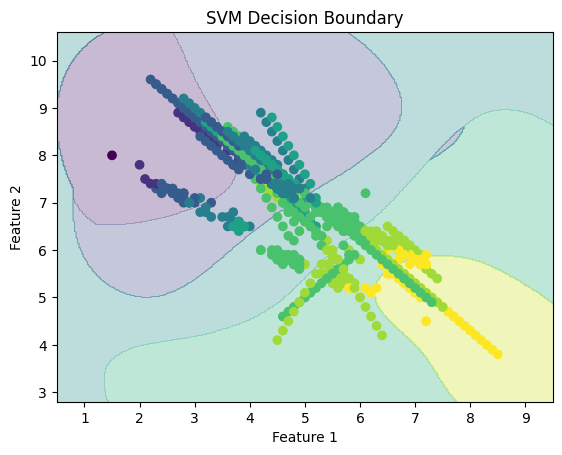

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm, datasets
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# print(df.head())
# # Load data
X = df.loc[:,["Avg_Daily_Usage_Hours", "Sleep_Hours_Per_Night"]]
y = df.Addicted_Score
print(X.head())
# print(X, y)

polynomial_svm_clf = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf", gamma="scale", C=1)
)
polynomial_svm_clf.fit(X, y)

# Train model
# model = svm.SVC(kernel='linear')
# model.fit(X, y)

# # Create grid
x_min, x_max = X["Avg_Daily_Usage_Hours"].min()-1, X["Avg_Daily_Usage_Hours"].max()+1
y_min, y_max = X["Sleep_Hours_Per_Night"].min()-1, X["Sleep_Hours_Per_Night"].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 350),
    np.linspace(y_min, y_max, 350)
)

# Predict all grid points
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = polynomial_svm_clf.predict(grid_points)

# Reshape for plotting
Z = Z.reshape(xx.shape)

# Plot decision regions
plt.contourf(xx, yy, Z, alpha=0.3)

# Plot real points
plt.scatter(X["Avg_Daily_Usage_Hours"], X['Sleep_Hours_Per_Night'],c=y)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("SVM Decision Boundary")

plt.show()

### Trying implementing with fewer target classes

       Student_ID         Age  Avg_Daily_Usage_Hours  Sleep_Hours_Per_Night  \
count  705.000000  705.000000             705.000000             705.000000   
mean   353.000000   20.659574               4.918723               6.868936   
std    203.660256    1.399217               1.257395               1.126848   
min      1.000000   18.000000               1.500000               3.800000   
25%    177.000000   19.000000               4.100000               6.000000   
50%    353.000000   21.000000               4.800000               6.900000   
75%    529.000000   22.000000               5.800000               7.700000   
max    705.000000   24.000000               8.500000               9.600000   

       Mental_Health_Score  Conflicts_Over_Social_Media  Addicted_Score  
count           705.000000                   705.000000      705.000000  
mean              6.226950                     2.849645        6.436879  
std               1.105055                     0.957968        1.5

/home/fourteenth/Documents/repos/pause-student-social-media-addiction-eda/eda/lib64/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


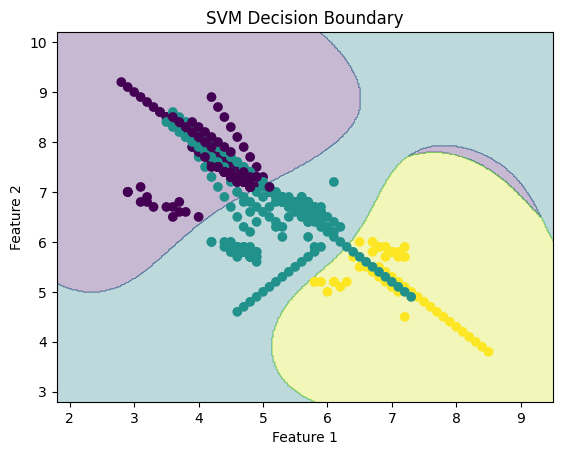

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm, datasets
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# print(df.head())
# # Load data
print(df.describe())
filtered_df = df[(df['Addicted_Score'] == 5) | (df['Addicted_Score'] == 7) | (df['Addicted_Score'] == 9)] #quartiles: 25% 50% max respectively

X = filtered_df.loc[:,["Avg_Daily_Usage_Hours", "Sleep_Hours_Per_Night"]]
y = filtered_df.Addicted_Score
print(X.head())
# print(X, y)

polynomial_svm_clf = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf", gamma="scale", C=1)
)
polynomial_svm_clf.fit(X, y)

# # Create grid
x_min, x_max = X["Avg_Daily_Usage_Hours"].min()-1, X["Avg_Daily_Usage_Hours"].max()+1
y_min, y_max = X["Sleep_Hours_Per_Night"].min()-1, X["Sleep_Hours_Per_Night"].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 350),
    np.linspace(y_min, y_max, 350)
)

# Predict all grid points
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = polynomial_svm_clf.predict(grid_points)

# Reshape for plotting
Z = Z.reshape(xx.shape)

# Plot decision regions
plt.contourf(xx, yy, Z, alpha=0.3)

# Plot real points
plt.scatter(X["Avg_Daily_Usage_Hours"], X['Sleep_Hours_Per_Night'],c=y)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("SVM Decision Boundary")

plt.show()

    Avg_Daily_Usage_Hours  Sleep_Hours_Per_Night
2                     6.0                    5.0
4                     4.5                    6.0
5                     7.2                    4.5
8                     4.0                    6.5
10                    4.8                    6.2


/home/fourteenth/Documents/repos/pause-student-social-media-addiction-eda/eda/lib64/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


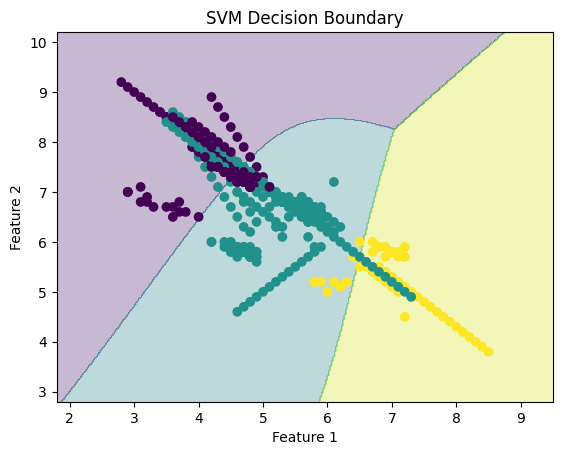

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm, datasets
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# print(df.head())
# # Load data
filtered_df = df[(df['Addicted_Score'] == 5) | (df['Addicted_Score'] == 7) | (df['Addicted_Score'] == 9)] #quartiles: 25% 50% max respectively

X = filtered_df.loc[:,["Avg_Daily_Usage_Hours", "Sleep_Hours_Per_Night"]]
y = filtered_df.Addicted_Score
print(X.head())
# print(X, y)

polynomial_svm_clf = make_pipeline(
    PolynomialFeatures(degree=3),
    StandardScaler(),
    LinearSVC(C=1, max_iter=10_000, random_state=42)
)
polynomial_svm_clf.fit(X, y)

# # Create grid
x_min, x_max = X["Avg_Daily_Usage_Hours"].min()-1, X["Avg_Daily_Usage_Hours"].max()+1
y_min, y_max = X["Sleep_Hours_Per_Night"].min()-1, X["Sleep_Hours_Per_Night"].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 350),
    np.linspace(y_min, y_max, 350)
)
# Predict all grid points
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = polynomial_svm_clf.predict(grid_points)

# Reshape for plotting
Z = Z.reshape(xx.shape)

# Plot decision regions
plt.contourf(xx, yy, Z, alpha=0.3)

# Plot real points
plt.scatter(X["Avg_Daily_Usage_Hours"], X['Sleep_Hours_Per_Night'],c=y)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("SVM Decision Boundary")

plt.show()

---

### scikit implementation example

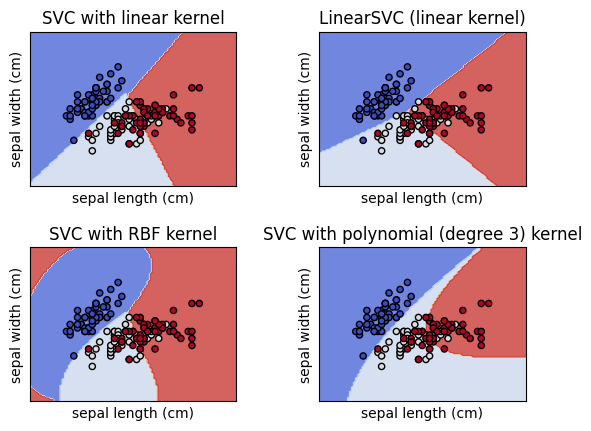

In [19]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

import matplotlib.pyplot as plt

from sklearn import datasets, svm
from sklearn.inspection import DecisionBoundaryDisplay

# import some data to play with
iris = datasets.load_iris()
# Take the first two features. We could avoid this by using a two-dim dataset
X = iris.data[:, :2]
y = iris.target

# we create an instance of SVM and fit out data. We do not scale our
# data since we want to plot the support vectors
C = 1.0  # SVM regularization parameter
models = (
    svm.SVC(kernel="linear", C=C),
    svm.LinearSVC(C=C, max_iter=10000),
    svm.SVC(kernel="rbf", gamma=0.7, C=C),
    svm.SVC(kernel="poly", degree=3, gamma="auto", C=C),
)
models = (clf.fit(X, y) for clf in models)

# title for the plots
titles = (
    "SVC with linear kernel",
    "LinearSVC (linear kernel)",
    "SVC with RBF kernel",
    "SVC with polynomial (degree 3) kernel",
)

# Set-up 2x2 grid for plotting.
fig, sub = plt.subplots(2, 2)
plt.subplots_adjust(wspace=0.4, hspace=0.4)

X0, X1 = X[:, 0], X[:, 1]

for clf, title, ax in zip(models, titles, sub.flatten()):
    disp = DecisionBoundaryDisplay.from_estimator(
        clf,
        X,
        response_method="predict",
        cmap=plt.cm.coolwarm,
        alpha=0.8,
        ax=ax,
        xlabel=iris.feature_names[0],
        ylabel=iris.feature_names[1],
    )
    ax.scatter(X0, X1, c=y, cmap=plt.cm.coolwarm, s=20, edgecolors="k")
    ax.set_xticks(())
    ax.set_yticks(())
    ax.set_title(title)

plt.show()

    Avg_Daily_Usage_Hours  Sleep_Hours_Per_Night
2                     6.0                    5.0
4                     4.5                    6.0
5                     7.2                    4.5
8                     4.0                    6.5
10                    4.8                    6.2


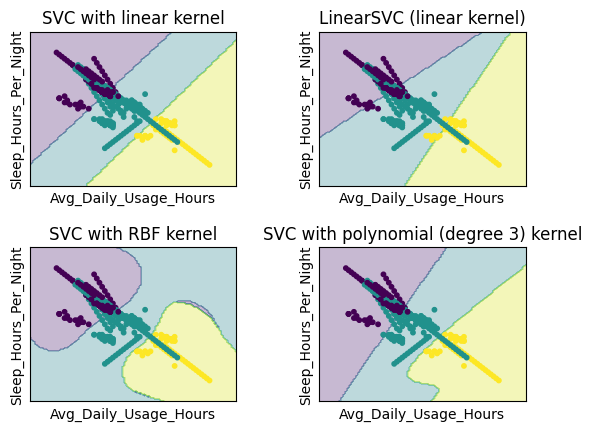

In [28]:
import matplotlib.pyplot as plt
from sklearn import datasets, svm
from sklearn.inspection import DecisionBoundaryDisplay

filtered_df = df[(df['Addicted_Score'] == 5) | (df['Addicted_Score'] == 7) | (df['Addicted_Score'] == 9)] #quartiles: 25% 50% max respectively

X = filtered_df.loc[:,["Avg_Daily_Usage_Hours", "Sleep_Hours_Per_Night"]]
y = filtered_df.Addicted_Score
print(X.head())

C = 1.0  # SVM regularization parameter
models = (
    svm.SVC(kernel="linear", C=C),
    svm.LinearSVC(C=C, max_iter=10000),
    svm.SVC(kernel="rbf", gamma=0.7, C=C),
    svm.SVC(kernel="poly", degree=3, gamma="auto", C=C),
)
models = (clf.fit(X, y) for clf in models)

# title for the plots
titles = (
    "SVC with linear kernel",
    "LinearSVC (linear kernel)",
    "SVC with RBF kernel",
    "SVC with polynomial (degree 3) kernel",
)

# Set-up 2x2 grid for plotting.
fig, sub = plt.subplots(2, 2)
plt.subplots_adjust(wspace=0.4, hspace=0.4)


for clf, title, ax in zip(models, titles, sub.flatten()):
    disp = DecisionBoundaryDisplay.from_estimator(
        clf,
        X,
        response_method="predict",
        alpha=0.3,
        ax=ax
    )
    ax.scatter(X["Avg_Daily_Usage_Hours"], X['Sleep_Hours_Per_Night'],c=y, s=10)
    ax.set_xticks(())
    ax.set_yticks(())
    ax.set_title(title)

plt.show()

[[5.1 3.5 1.4]
 [4.9 3.  1.4]
 [4.7 3.2 1.3]
 [4.6 3.1 1.5]
 [5.  3.6 1.4]
 [5.4 3.9 1.7]
 [4.6 3.4 1.4]
 [5.  3.4 1.5]
 [4.4 2.9 1.4]
 [4.9 3.1 1.5]
 [5.4 3.7 1.5]
 [4.8 3.4 1.6]
 [4.8 3.  1.4]
 [4.3 3.  1.1]
 [5.8 4.  1.2]
 [5.7 4.4 1.5]
 [5.4 3.9 1.3]
 [5.1 3.5 1.4]
 [5.7 3.8 1.7]
 [5.1 3.8 1.5]
 [5.4 3.4 1.7]
 [5.1 3.7 1.5]
 [4.6 3.6 1. ]
 [5.1 3.3 1.7]
 [4.8 3.4 1.9]
 [5.  3.  1.6]
 [5.  3.4 1.6]
 [5.2 3.5 1.5]
 [5.2 3.4 1.4]
 [4.7 3.2 1.6]
 [4.8 3.1 1.6]
 [5.4 3.4 1.5]
 [5.2 4.1 1.5]
 [5.5 4.2 1.4]
 [4.9 3.1 1.5]
 [5.  3.2 1.2]
 [5.5 3.5 1.3]
 [4.9 3.6 1.4]
 [4.4 3.  1.3]
 [5.1 3.4 1.5]
 [5.  3.5 1.3]
 [4.5 2.3 1.3]
 [4.4 3.2 1.3]
 [5.  3.5 1.6]
 [5.1 3.8 1.9]
 [4.8 3.  1.4]
 [5.1 3.8 1.6]
 [4.6 3.2 1.4]
 [5.3 3.7 1.5]
 [5.  3.3 1.4]
 [7.  3.2 4.7]
 [6.4 3.2 4.5]
 [6.9 3.1 4.9]
 [5.5 2.3 4. ]
 [6.5 2.8 4.6]
 [5.7 2.8 4.5]
 [6.3 3.3 4.7]
 [4.9 2.4 3.3]
 [6.6 2.9 4.6]
 [5.2 2.7 3.9]
 [5.  2.  3.5]
 [5.9 3.  4.2]
 [6.  2.2 4. ]
 [6.1 2.9 4.7]
 [5.6 2.9 3.6]
 [6.7 3.1 4.4]
 [5.6 3.  

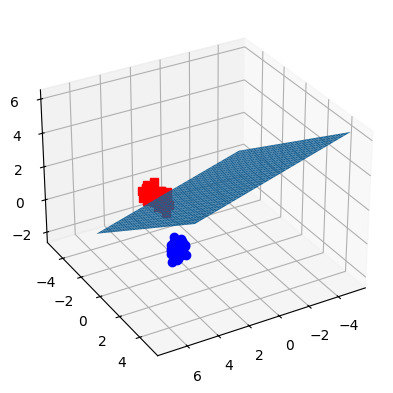

In [87]:
# Source - https://stackoverflow.com/a/61226259
# Posted by seralouk, modified by community. See post 'Timeline' for change history
# Retrieved 2026-05-11, License - CC BY-SA 4.0

from sklearn.svm import SVC
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm, datasets
from mpl_toolkits.mplot3d import Axes3D

iris = datasets.load_iris()
X = iris.data[:, :3]  # we only take the first three features.
Y = iris.target

#make it binary classification problem
print(X)
print(type(X[Y==0,0]), X[Y==0,0])
X = X[np.logical_or(Y==0,Y==1)]
Y = Y[np.logical_or(Y==0,Y==1)]

model = svm.SVC(kernel='linear')
clf = model.fit(X, Y)

# The equation of the separating plane is given by all x so that np.dot(svc.coef_[0], x) + b = 0.
# Solve for w3 (z)
z = lambda x,y: (-clf.intercept_[0]-clf.coef_[0][0]*x -clf.coef_[0][1]*y) / clf.coef_[0][2]

tmp = np.linspace(-5,5,30)
x,y = np.meshgrid(tmp,tmp)
print(type(X[Y==0,0]), X[Y==0,0])
fig = plt.figure()
ax  = fig.add_subplot(111, projection='3d')
ax.plot3D(X[Y==0,0], X[Y==0,1], X[Y==0,2],'ob')
ax.plot3D(X[Y==1,0], X[Y==1,1], X[Y==1,2],'sr')
ax.plot_surface(x, y, z(x,y))
ax.view_init(30, 60)
plt.show()


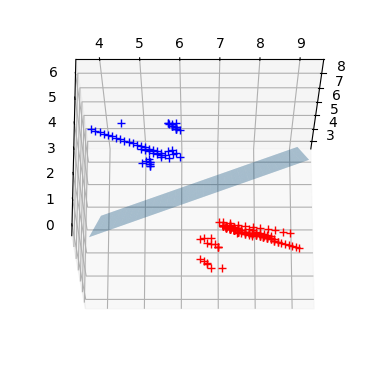

In [109]:
# Source - https://stackoverflow.com/a/61226259
# Posted by seralouk, modified by community. See post 'Timeline' for change history
# Retrieved 2026-05-11, License - CC BY-SA 4.0

from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
import numpy as np
import matplotlib.pyplot as plt
# from sklearn import svm
# from mpl_toolkits.mplot3d import Axes3D
# from sklearn.preprocessing import PolynomialFeatures, StandardScaler
# from sklearn.svm import LinearSVC


filtered_df = df[(df['Addicted_Score'] == 5) | (df['Addicted_Score'] == 9)] #quartiles: 25% max respectively
# filtered_df = df[(df['Addicted_Score'] == 5) | (df['Addicted_Score'] == 9) | (df['Addicted_Score'] == 7)] #quartiles: 25% 50% max respectively
X = filtered_df.loc[:,["Avg_Daily_Usage_Hours", "Sleep_Hours_Per_Night", "Conflicts_Over_Social_Media"]]
Y = filtered_df.Addicted_Score

# polynomial_svm_clf = make_pipeline(
#     PolynomialFeatures(degree=3),
#     StandardScaler(),
#     LinearSVC(C=1, max_iter=10_000, random_state=42)
# )
# polynomial_svm_clf.fit(X, Y)
clf = make_pipeline(
    StandardScaler(),
    SVC(kernel='linear')
)
model = svm.SVC(kernel='linear')
clf = model.fit(X, Y)

# The equation of the separating plane is given by all x so that np.dot(svc.coef_[0], x) + b = 0.
# Solve for w3 (z)
# print(clf.intercept_[0], clf.coef_[0])
z = lambda x,y: (-clf.intercept_[0]-clf.coef_[0][0]*x -clf.coef_[0][1]*y) / clf.coef_[0][2]
# print(X, Y)

# create mesh using limits for x and y
xlim = [X.iloc[:,0].min(), X.iloc[:,0].max()]
ylim = [X.iloc[:,1].min(), X.iloc[:,1].max()]
xx, yy = np.meshgrid(
    np.linspace(xlim[0], xlim[1], 30),
    np.linspace(ylim[0], ylim[1], 30)
)
fig = plt.figure()
ax  = fig.add_subplot(111, projection='3d')
X = X.to_numpy()
# print(X[Y==5,0])
ax.plot3D(X[Y==5,0], X[Y==5,1], X[Y==5,2],'+r')
# ax.plot3D(X[Y==7,0], X[Y==7,1], X[Y==7,2],'+g')
ax.plot3D(X[Y==9,0], X[Y==9,1], X[Y==9,2],'+b')
ax.plot_surface(xx, yy, z(xx,yy), alpha=0.4)
ax.view_init(-20,0)
plt.show()


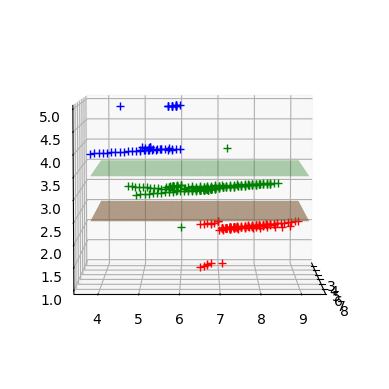

In [ ]:
# Source - https://stackoverflow.com/a/61226259
# Posted by seralouk, modified by community. See post 'Timeline' for change history
# Retrieved 2026-05-11, License - CC BY-SA 4.0

from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.preprocessing import StandardScaler
import plotly.io as pio
from IPython.display import HTML

# from sklearn import svm
# from mpl_toolkits.mplot3d import Axes3D
# from sklearn.preprocessing import PolynomialFeatures, StandardScaler
# from sklearn.svm import LinearSVC


# filtered_df = df[(df['Addicted_Score'] == 5) | (df['Addicted_Score'] == 9)] #quartiles: 25% max respectively
filtered_df = df[(df['Addicted_Score'] == 5) | (df['Addicted_Score'] == 9) | (df['Addicted_Score'] == 7)] #quartiles: 25% 50% max respectively
X = filtered_df.loc[:,["Avg_Daily_Usage_Hours", "Sleep_Hours_Per_Night", "Conflicts_Over_Social_Media"]]
Y = filtered_df.Addicted_Score

# polynomial_svm_clf = make_pipeline(
#     PolynomialFeatures(degree=3),
#     StandardScaler(),
#     LinearSVC(C=1, max_iter=10_000, random_state=42)
# )
# polynomial_svm_clf.fit(X, Y)
# clf1 = make_pipeline(
#     StandardScaler()
# )

clf1 = SVC(kernel='linear').fit(X, Y == 5)
clf2 = SVC(kernel='linear').fit(X, Y == 7)
clf3 = SVC(kernel='linear').fit(X, Y == 9)

# The equation of the separating plane is given by all x so that np.dot(svc.coef_[0], x) + b = 0.
# Solve for w3 (z)
# print(clf.intercept_[0], clf.coef_[0])
z1 = lambda x,y: (-clf1.intercept_[0]-clf1.coef_[0][0]*x -clf1.coef_[0][1]*y) / clf1.coef_[0][2]
z2 = lambda x,y: (-clf2.intercept_[0]-clf2.coef_[0][0]*x -clf2.coef_[0][1]*y) / clf2.coef_[0][2]
z3 = lambda x,y: (-clf3.intercept_[0]-clf3.coef_[0][0]*x -clf3.coef_[0][1]*y) / clf3.coef_[0][2]
# print(X, Y)

# create mesh using limits for x and y
xlim = [X.iloc[:,0].min(), X.iloc[:,0].max()]
ylim = [X.iloc[:,1].min(), X.iloc[:,1].max()]
xx, yy = np.meshgrid(
    np.linspace(xlim[0], xlim[1], 30),
    np.linspace(ylim[0], ylim[1], 30)
)
fig = plt.figure()
ax  = fig.add_subplot(111, projection='3d')
X = X.to_numpy()
# print(X[Y==5,0])
ax.plot3D(X[Y==5,0], X[Y==5,1], X[Y==5,2],'+r')
ax.plot3D(X[Y==7,0], X[Y==7,1], X[Y==7,2],'+g')
ax.plot3D(X[Y==9,0], X[Y==9,1], X[Y==9,2],'+b')
ax.plot_surface(xx, yy, z1(xx,yy), alpha=0.4)
ax.plot_surface(xx, yy, z2(xx,yy), alpha=0.4)
ax.plot_surface(xx, yy, z3(xx,yy), alpha=0.4)
ax.view_init(5,0)
plt.show()
